# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Implementing Q-learning with the FrozenLake-v1 environment

In [5]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random
import numpy as np
import matplotlib.pyplot as plt

1. ĐANG HUẤN LUYỆN (TRAINING) AGENT...
Huấn luyện xong! Bắt đầu đánh giá...


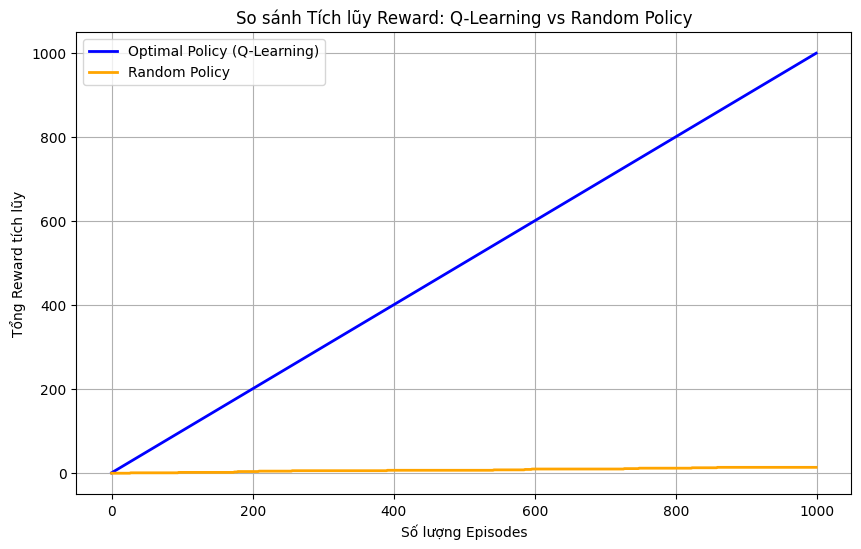

Training completed. Q-table:
State: 0, Action: 0, Q-value: 0.49
State: 0, Action: 1, Q-value: 0.28
State: 0, Action: 2, Q-value: 0.59
State: 0, Action: 3, Q-value: 0.51
State: 1, Action: 0, Q-value: 0.46
State: 1, Action: 1, Q-value: 0.00
State: 1, Action: 2, Q-value: 0.66
State: 1, Action: 3, Q-value: 0.53
State: 2, Action: 0, Q-value: 0.54
State: 2, Action: 1, Q-value: 0.73
State: 2, Action: 2, Q-value: 0.41
State: 2, Action: 3, Q-value: 0.63
State: 3, Action: 0, Q-value: 0.60
State: 3, Action: 1, Q-value: 0.00
State: 3, Action: 2, Q-value: 0.10
State: 3, Action: 3, Q-value: 0.00
State: 4, Action: 0, Q-value: 0.00
State: 4, Action: 1, Q-value: 0.00
State: 4, Action: 2, Q-value: 0.00
State: 4, Action: 3, Q-value: 0.46
State: 6, Action: 0, Q-value: 0.00
State: 6, Action: 1, Q-value: 0.81
State: 6, Action: 2, Q-value: 0.00
State: 6, Action: 3, Q-value: 0.61
State: 8, Action: 0, Q-value: 0.00
State: 8, Action: 1, Q-value: 0.00
State: 8, Action: 2, Q-value: 0.00
State: 8, Action: 3, Q-val

C:\Users\phat4\AppData\Roaming\Python\Python312\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===
Step 1 - Action: 2, Reward: 0
Step 2 - Action: 2, Reward: 0
Step 3 - Action: 1, Reward: 0
Step 4 - Action: 1, Reward: 0
Step 5 - Action: 1, Reward: 0
Step 6 - Action: 2, Reward: 1
Agent reached the goal!


In [6]:
# ============================================================
# Q-learning agent for Gymnasium FrozenLake-v1
# ------------------------------------------------------------
# This script trains an agent to learn a state-action value table
# Q(s, a) using the Q-learning algorithm and an epsilon-greedy policy.
#
# Environment:
# - FrozenLake-v1 (4x4 by default)
# - is_slippery=False -> deterministic movement (easier learning)
#
# High-level flow:
# 1) Create environment and agent
# 2) Train over many episodes
# 3) Print and export learned Q-table
# 4) Demonstrate the learned policy in text mode and pygame mode
# ============================================================


class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        # Return Q(s, a). If missing, return 0.0 (default for unseen pairs).
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        # Q-learning update rule:
        #   Q(s,a) <- (1 - alpha)*Q(s,a) + alpha*(reward + gamma*max_a' Q(s',a'))
        #
        # 1) Estimate best possible future value at next_state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_next_q = max(
            self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        # 2) Current estimate for (state, action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        current_q = self.get_q_value(state, action)

        # 3) Temporal-difference target
        # Reward for current step + discounted best future value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        target_q = reward + self.gamma*best_next_q

        # 4) Blend old estimate with new target
        # New Q-value is a weighted average of old and new information
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        new_q = (1-self.alpha)*current_q + self.alpha*target_q

        # 5) Save updated Q-value
        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1, option="q_learning"):
        if option == "random":
            return self.env.action_space.sample()
        # Epsilon-greedy action selection:
        # - With probability epsilon: explore (random action)
        # - Otherwise: exploit (choose action with highest Q-value)

        # 1) Exploration: random action with probability epsilon
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if random.random() < epsilon:
            return self.env.action_space.sample()

        # Compute Q-values for all actions in current state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)

        # Tie-breaking: if multiple actions share max Q, choose randomly among them
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_actions = [
            a for a in range(self.env.action_space.n)
            if q_values[a] == max_q
        ]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        # Pure greedy policy (epsilon=0):
        # Always choose one of the best actions by Q-value.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)


def export_q_table_to_txt(agent, file_path="q_table_final.txt"):
    """Export all learned Q-values to a CSV-like text file.

    File format:
        State,Action,Q-value
        0,0,0.000000
        ...
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write("State,Action,Q-value\n")
        # Sort keys for stable, readable output
        for (state, action) in sorted(agent.q_table.keys()):
            q_val = agent.q_table[(state, action)]
            f.write(f"{state},{action},{q_val:.6f}\n")
    print(f"Q-table exported to: {file_path}")


def show_final_result_text(agent):
    """Run one full evaluation episode in ANSI text mode.

    - Uses a greedy policy (no exploration).
    - Prints board state after each step.
    - Useful for notebook/terminal environments.
    """
    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (TEXT) ===")
    print(demo_env.render())

    done = False
    step = 0
    reward = 0

    while not done:
        # Pick best action according to learned Q-table
        action = agent.choose_greedy_action(state)

        # Interact with environment
        next_state, reward, terminated, truncated, _ = demo_env.step(action)

        # Episode stops if goal/hole reached (terminated) or cutoff (truncated)
        done = terminated or truncated
        step += 1

        # Log progress and render current map
        print(f"Step {step} - Action: {action}, Reward: {reward}")
        print(demo_env.render())

        # Move to next state
        state = next_state

    # Final status
    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")
    demo_env.close()


def show_final_result_pygame(agent, delay_seconds=0.5):
    """
    Run one full evaluation episode with GUI rendering ("human" mode).

    Note:
    - Requires a local environment that supports opening windows.
    - In remote/notebook servers without display, this may not work.
    """
    import time

    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===")
    done = False
    step = 0
    reward = 0

    while not done:
        action = agent.choose_greedy_action(state)
        next_state, reward, terminated, truncated, _ = demo_env.step(action)
        done = terminated or truncated
        step += 1

        print(f"Step {step} - Action: {action}, Reward: {reward}")
        state = next_state

        # Slow down transitions so movement can be observed clearly
        time.sleep(delay_seconds)

    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")

    # Keep final frame visible briefly
    time.sleep(1.0)
    demo_env.close()


# ============================================================
# Training routine
# ============================================================

if __name__ == "__main__":
    # Create deterministic FrozenLake environment for training
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    env = gym.make("FrozenLake-v1", is_slippery=False)

    # Initialize Q-learning agent with default hyperparameters
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    agent = QLearningAgent(env)

    # Number of independent training episodes
    num_episodes = 1000

    print("1. ĐANG HUẤN LUYỆN (TRAINING) AGENT...")
    # ==========================================
    # PHẦN 1: HUẤN LUYỆN (Bắt buộc phải có)
    # ==========================================
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            # Chọn hành động có exploration (epsilon=0.1)
            action = agent.choose_action(state, epsilon=0.1)
            
            # Thực thi
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Cập nhật bảng Q-Table (Agent HỌC ở bước này)
            agent.update_q_value(state, action, reward, next_state)
            
            state = next_state

    print("Huấn luyện xong! Bắt đầu đánh giá...")

    q_learning_rewards = []
    random_rewards = []

    # Optimal Policy(Q-Learning)
    for _ in range(num_episodes):
        # Reset environment at start of each episode
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            # Dùng hàm choose_greedy_action để chạy tối ưu (không khám phá nữa)
            action = agent.choose_greedy_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
        q_learning_rewards.append(episode_reward)

    # Random Policy
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            # Dùng tuỳ chọn option="random" đã thêm ở trên
            action = agent.choose_action(state, option="random")
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
        random_rewards.append(episode_reward)

    cum_q_rewards = np.cumsum(q_learning_rewards)
    cum_random_rewards = np.cumsum(random_rewards)

    plt.figure(figsize=(10, 6))
    plt.plot(cum_q_rewards, label="Optimal Policy (Q-Learning)", color="blue", linewidth=2)
    plt.plot(cum_random_rewards, label="Random Policy", color="orange", linewidth=2)
    
    plt.title("So sánh Tích lũy Reward: Q-Learning vs Random Policy")
    plt.xlabel("Số lượng Episodes")
    plt.ylabel("Tổng Reward tích lũy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print learned Q-table entries
    print("Training completed. Q-table:")
    for (state, action) in sorted(agent.q_table.keys()):
        q_val = agent.q_table[(state, action)]
        print(f"State: {state}, Action: {action}, Q-value: {q_val:.2f}")

    # Save Q-table to file for later inspection/use
    export_q_table_to_txt(agent, "q_table_final.txt")

    # Show one text-based demonstration run
    show_final_result_text(agent)

    # Show one GUI-based demonstration run
    show_final_result_pygame(agent, delay_seconds=0.4)

    # Release training environment resources
    env.close()